In [2]:
import tensorflow as tf
print(tf.__version__)

# test code to verify TensorFlow installation

2.20.0


In [3]:
# Create a constant tensor
a = tf.constant([[1, 2], [3, 4]])
print(a)
print(a.shape)


tf.Tensor(
[[1 2]
 [3 4]], shape=(2, 2), dtype=int32)
(2, 2)


In [ ]:
import tensorflow as tf

#  scalor
a = tf.constant(5)

#  vector
b = tf.constant([1, 2, 3])

# matrix
c = tf.constant([[1, 2], [3, 4]])

print(a)
print(b)
print(c)
print("Shape of c:", c.shape)


tf.Tensor(5, shape=(), dtype=int32)
tf.Tensor([1 2 3], shape=(3,), dtype=int32)
tf.Tensor(
[[1 2]
 [3 4]], shape=(2, 2), dtype=int32)
Shape of c: (2, 2)


In [10]:
import tensorflow as tf 
import numpy as np 
 
print("TF:", tf.__version__) 
 
# 1) Scalars, vectors, matrices, tensors 
scalar = tf.constant(7)  # rank-0 
vector = tf.constant([10, 20, 30]) # rank-1 
matrix = tf.constant([[1., 2.], [3., 4.]])  # rank-2 
tensor  = tf.constant([[[1],[2]], [[3],[4]]]) # rank-3 (2x2x1) 
 
print(scalar.shape, vector.shape, matrix.shape, tensor.shape) 
 
# 2) Dtypes and casting 
x = tf.constant([1.7, 7.4]) # float32 default 
y = tf.constant([7, 10]) # int32 default 
x16 = tf.cast(x, tf.float16) # reduced precision floats 
y32 = tf.cast(y, tf.float32) # cast ints → floats 
 
# 3) Indexing and shaping 
rank2 = tf.constant([[10, 7], [3, 4]]) 
last_col = rank2[:, -1] # column slice 
expanded = tf.expand_dims(rank2, -1) # add channel-like axis
squeezed = tf.squeeze(expanded, axis=-1) 
 
# 4) Broadcasting & basic ops 
A = tf.constant([[10., 7.], [3., 4.]]) 
print("A+10:\n", A + 10) 
print("A*2:\n", A * 2) 
 
# 5) Matrix multiplication rules (inner dims match) 
X = tf.constant([[1, 2], [3, 4], [5, 6]], dtype=tf.float32)  # (3x2) 
Y = tf.constant([[7, 8], [9, 10], [11, 12]], dtype=tf.float32) # (3x2) 
XtY = tf.matmul(X, tf.transpose(Y))     # (3x2) @ (2x3) -> (3x3) 
 
# 6) Aggregations 
E = tf.constant(np.random.randint(0, 100, size=10)) 
print("min:", tf.reduce_min(E).numpy(), 
      "max:", tf.reduce_max(E).numpy(), 
      "mean:", tf.reduce_mean(tf.cast(E, tf.float32)).numpy(), 
      "sum:", tf.reduce_sum(E).numpy()) 
 
# 7) One-hot encoding 
idx = tf.constant([0, 1, 2, 3]) 
oh  = tf.one_hot(idx, depth=4) 
 
# 8) NumPy interop 
arr = np.array([3., 7., 10.]) 
t   = tf.constant(arr) # NumPy -> Tensor 
back_to_np = t.numpy() # Tensor -> NumPy 
 
print("OK")

TF: 2.20.0
() (3,) (2, 2) (2, 2, 1)
A+10:
 tf.Tensor(
[[20. 17.]
 [13. 14.]], shape=(2, 2), dtype=float32)
A*2:
 tf.Tensor(
[[20. 14.]
 [ 6.  8.]], shape=(2, 2), dtype=float32)
min: 5 max: 99 mean: 54.4 sum: 544
OK


Test MAE: 16.019407272338867
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


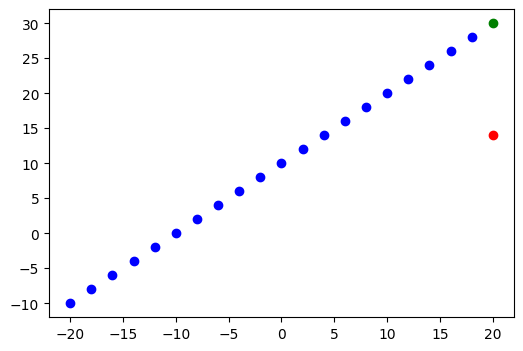

In [11]:
import tensorflow as tf 
import numpy as np 
import matplotlib.pyplot as plt 
# Synthetic linear data 
X = np.arange(-20, 21, 2, dtype=np.float32)  # [-20, -18, ..., 20] 
y = X + 10 
# Train/test split (simple)
X_train, y_train = X[:20], y[:20] 
X_test,  y_test  = X[20:], y[20:] 
 
# 1) CREATE 
model = tf.keras.Sequential([ 
    tf.keras.layers.Input(shape=(1,)), 
    tf.keras.layers.Dense(1)  # linear output for regression 
]) 
 
# 2) COMPILE 
model.compile( 
    loss="mae", 
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01), 
    metrics=["mae"] 
) 
 
# 3) FIT 
history = model.fit(X_train, y_train, epochs=200, verbose=0) 
 
# Evaluate 
loss, mae = model.evaluate(X_test, y_test, verbose=0) 
print("Test MAE:", mae) 
 
# Predict and visualize 
y_pred = model.predict(X_test).squeeze() 
 
plt.figure(figsize=(6,4)) 
plt.scatter(X_train, y_train, c='b', label='Train') 
plt.scatter(X_test,  y_test,  c='g', label='Test') 
plt.scatter(X_test,  y_pred,  c='r', label='Pred')

Test accuracy: 0.995


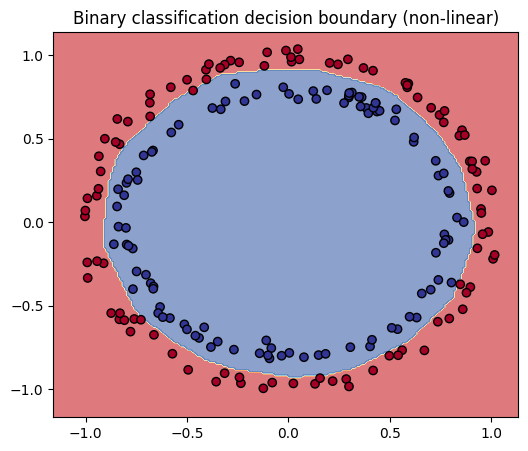

In [12]:
import tensorflow as tf 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split 
 
# Non-linear separable data 
X, y = make_circles(n_samples=1000, noise=0.03, random_state=42) 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42) 
 
# 1) CREATE (use non-linear activations + sigmoid output) 
model = tf.keras.Sequential([ 
    tf.keras.layers.Input(shape=(2,)), 
    tf.keras.layers.Dense(16, activation="relu"), 
    tf.keras.layers.Dense(16, activation="relu"), 
    tf.keras.layers.Dense(1, activation="sigmoid") 
]) 
 
# 2) COMPILE 
model.compile( 
    loss="binary_crossentropy", 
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), 
    metrics=["accuracy"] 
) 
 
# 3) FIT 
history = model.fit(X_train, y_train, epochs=25, verbose=0) 
 
# Evaluate 
loss, acc = model.evaluate(X_test, y_test, verbose=0) 
print(f"Test accuracy: {acc:.3f}") 
 
# Visualize decision boundary
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.1, X[:,0].max()+0.1, 200), 
                     np.linspace(X[:,1].min()-0.1, X[:,1].max()+0.1, 200)) 
grid = np.c_[xx.ravel(), yy.ravel()] 
probs = model.predict(grid, verbose=0).reshape(xx.shape) 
 
plt.figure(figsize=(6,5)) 
plt.contourf(xx, yy, (probs>0.5).astype(int), cmap=plt.cm.RdYlBu, alpha=0.6) 
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap=plt.cm.RdYlBu, edgecolor='k') 
plt.title("Binary classification decision boundary (non-linear)") 
plt.show() 

Test accuracy: 0.8813999891281128
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


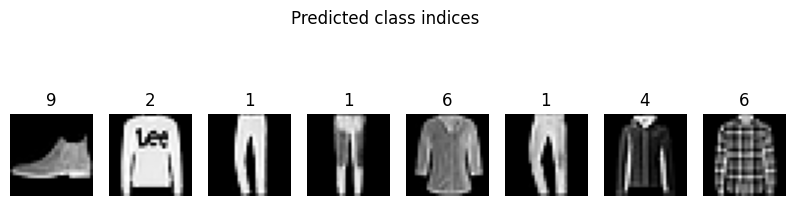

In [15]:
# Multiclass classification with Fashion‑MNIST
import tensorflow as tf 
import matplotlib.pyplot as plt 
# Load Fashion-MNIST 
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data() 
 
# Normalize to [0,1] 
x_train = x_train.astype("float32")/255.0 
x_test  = x_test.astype("float32")/255.0 
 
# 1) CREATE (flatten > Dense ReLU > Dense softmax) 
model = tf.keras.Sequential([ 
    tf.keras.layers.Input(shape=(28, 28)), 
    tf.keras.layers.Flatten(), 
    tf.keras.layers.Dense(128, activation="relu"), 
    tf.keras.layers.Dense(10, activation="softmax") 
])
# 2) COMPILE 
model.compile( 
    loss="sparse_categorical_crossentropy",  # labels are ints, not one-hot 
    optimizer="adam", 
    metrics=["accuracy"] 
) 
 
# 3) FIT 
history = model.fit(x_train, y_train, epochs=10, validation_split=0.1, verbose=0) 
 
# Evaluate 
loss, acc = model.evaluate(x_test, y_test, verbose=0) 
print("Test accuracy:", acc) 
 
# Show a few preds 
preds = model.predict(x_test[:8]).argmax(axis=1) 
plt.figure(figsize=(10,3)) 
for i in range(8): 
    plt.subplot(1,8,i+1) 
    plt.imshow(x_test[i], cmap='gray') 
    plt.title(int(preds[i])) 
    plt.axis('off') 
plt.suptitle("Predicted class indices"); plt.show() 

In [16]:
# CNNs for Images 
import tensorflow as tf 
import numpy as np 
import matplotlib.pyplot as plt 
 
# Use Fashion-MNIST but map 2 classes to a binary task (e.g., class 9=Ankle boot vs 7=Sneaker) 
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data() 
# Keep only classes 7 and 9 
train_mask = np.isin(y_train, [7, 9]) 
test_mask  = np.isin(y_test,  [7, 9]) 
 
x_train = x_train[train_mask][..., None]/255.0 
y_train = (y_train[train_mask] == 9).astype(np.float32)  # 1 if class 9 else 0 
x_test  = x_test[test_mask][..., None]/255.0 
y_test  = (y_test[test_mask] == 9).astype(np.float32) 

# 1) CREATE (small CNN) 
model = tf.keras.Sequential([ 
    tf.keras.layers.Input(shape=(28,28,1)), 
    tf.keras.layers.Conv2D(16, 3, activation="relu"), 
    tf.keras.layers.MaxPool2D(), 
    tf.keras.layers.Conv2D(32, 3, activation="relu"), 
    tf.keras.layers.MaxPool2D(), 
    tf.keras.layers.Flatten(), 
    tf.keras.layers.Dense(64, activation="relu"), 
    tf.keras.layers.Dense(1, activation="sigmoid") 
]) 
 
# 2) COMPILE 
model.compile( 
    loss="binary_crossentropy", 
    optimizer="adam", 
    metrics=["accuracy"] 
) 
 
# 3) FIT 
history = model.fit(x_train, y_train, epochs=5, validation_split=0.1, verbose=0) 
 
# Evaluate 
loss, acc = model.evaluate(x_test, y_test, verbose=0) 
print("Test accuracy:", acc)

Test accuracy: 0.965499997138977


In [18]:
#  Transfer Learning (Feature Extraction) 

import tensorflow as tf 
from tensorflow.keras import layers, models 
# Data  
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data() 
 
# Keep classes 0,1,2 only 
mask_train = (y_train < 3).flatten() 
mask_test  = (y_test  < 3).flatten() 
x_train = x_train[mask_train].astype("float32")/255.0 
y_train = y_train[mask_train].flatten() 
x_test  = x_test[mask_test].astype("float32")/255.0 
y_test  = y_test[mask_test].flatten() 
 
# Small CNN model  
model = models.Sequential([ 
    layers.Conv2D(32, (3,3), activation="relu", padding="same", input_shape=(32,32,3)), 
    layers.MaxPooling2D(), 
 
    layers.Conv2D(64, (3,3), activation="relu", padding="same"), 
    layers.MaxPooling2D(), 
 
    layers.Conv2D(128, (3,3), activation="relu", padding="same"), 
    layers.MaxPooling2D(), 
 
    layers.Flatten(), 
    layers.Dense(64, activation="relu"), 
    layers.Dense(3, activation="softmax") 
]) 
 
model.compile( 
    optimizer="adam", 
    loss="sparse_categorical_crossentropy", 
    metrics=["accuracy"]

) 
 
# Train  
history = model.fit( 
    x_train, y_train, 
    epochs=5, 
    batch_size=64, 
    validation_split=0.1, 
    verbose=1 
) 
 
# Evaluate 
loss, acc = model.evaluate(x_test, y_test, verbose=0) 
print("Test accuracy (tiny CNN):", acc)

c:\Users\zxcv0\miniforge3\envs\ryzen-ai-1.5.1\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.7404 - loss: 0.6167 - val_accuracy: 0.8547 - val_loss: 0.4084
Epoch 2/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8398 - loss: 0.4046 - val_accuracy: 0.8753 - val_loss: 0.3386
Epoch 3/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8723 - loss: 0.3237 - val_accuracy: 0.9000 - val_loss: 0.2842
Epoch 4/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8916 - loss: 0.2778 - val_accuracy: 0.9080 - val_loss: 0.2768
Epoch 5/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9076 - loss: 0.2432 - val_accuracy: 0.9033 - val_loss: 0.2829
Test accuracy (tiny CNN): 0.8816666603088379
